# 01 — Import & Exploratory Data Analysis — CIC-IDS-2017 — Mutual Information study

**Study:** top-40-feature multi-split comparison of 5 ML algorithms, with features
selected by **Mutual Information** (filter method). Same protocol as the base (RF-importance) study;
only the selection technique differs, so any performance difference is attributable
to the feature set. This set is for **CIC-IDS-2017 only** — never combined with the other
dataset. Artifacts go to `artifacts/ft40_mi/cic2017/`.

If the base study already imported this dataset (`artifacts/ft40/cic2017/data/raw_unified.parquet`),
that parquet is **reused automatically** — same rows, no second CSV import.

In [1]:
DATASET = "cic2017"
FT_ROOT = "ft40_mi"          # resolves under backend/artifacts/
ROWS_PER_FILE_2018 = 200_000   # stratified sample per 2018 CSV (2017 is always read in full)
RAW_SOURCE = None              # optional unified parquet to reuse (None = auto-detect base study)
SMOKE_SAMPLE_ROWS = None       # smoke-testing only: subsample to this many rows
REBUILD = False                # True = re-read raw CSVs even if raw_unified.parquet exists

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids import config
from ids.schema import CANONICAL_COLUMNS, LABEL_COLUMN
from ids.data.loaders import read_full, read_and_sample
from ids.data.unify import unify_2017, unify_2018, concat_unified
from ids.data.labels import normalize_labels

if SMOKE_SAMPLE_ROWS and not str(FT_ROOT or "").startswith("/private"):
    raise ValueError("smoke runs must set FT_ROOT to a scratch directory")

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "01_load_and_eda.log", "nb01")
log.info("dataset=%s | random_state=%d | artifacts -> %s", DATASET, config.RANDOM_STATE, P.root)
RAW_PATH = P.data / "raw_unified.parquet"

if RAW_SOURCE is None:
    base_raw = config.ARTIFACTS_DIR / "ft40" / DATASET / "data" / "raw_unified.parquet"
    if base_raw.exists():
        RAW_SOURCE = str(base_raw)
        log.info("base study import found — reusing %s", RAW_SOURCE)

2026-07-06 11:16:59,377 INFO nb01: dataset=cic2017 | random_state=42 | artifacts -> /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2017
2026-07-06 11:16:59,378 INFO nb01: base study import found — reusing /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2017/data/raw_unified.parquet


## 1. Import the raw dataset

Reused from the base study when available (identical rows guarantee comparability).
Otherwise: 2017 reads all 8 daily CSVs **in full**; 2018 stratified-samples each of the
10 daily CSVs to `ROWS_PER_FILE_2018` rows. Either path is renamed to the canonical
77-feature schema and label-normalized (`BENIGN`/`Benign` → `Benign`).

In [3]:
if RAW_PATH.exists() and not REBUILD:
    with nbc.timed(log, f"load cached {RAW_PATH.name}"):
        raw = pd.read_parquet(RAW_PATH)
else:
    if RAW_SOURCE and Path(RAW_SOURCE).exists():
        with nbc.timed(log, f"load pre-built unified parquet {RAW_SOURCE}"):
            raw = pd.read_parquet(RAW_SOURCE)
    else:
        if RAW_SOURCE:
            log.warning("RAW_SOURCE %s not found — importing from CSVs", RAW_SOURCE)
        src_dir = config.CIC2017_DIR if DATASET == "cic2017" else config.CIC2018_DIR
        csvs = sorted(src_dir.glob("*.csv"))
        log.info("importing %d raw CSV files from %s", len(csvs), src_dir)
        frames = []
        for csv_path in csvs:
            with nbc.timed(log, f"read {csv_path.name}"):
                if DATASET == "cic2017":
                    df = unify_2017(read_full(csv_path))
                else:
                    df = unify_2018(read_and_sample(
                        csv_path, rows_per_file=ROWS_PER_FILE_2018,
                        random_state=config.RANDOM_STATE))
            log.info("%s -> %d rows", csv_path.name, len(df))
            frames.append(df)
        raw = concat_unified(frames)
        raw[LABEL_COLUMN] = normalize_labels(raw[LABEL_COLUMN])

    if SMOKE_SAMPLE_ROWS:
        counts = raw[LABEL_COLUMN].value_counts()
        raw = raw[raw[LABEL_COLUMN].isin(counts[counts >= 200].index)]
        frac = min(1.0, SMOKE_SAMPLE_ROWS / len(raw))
        raw = (raw.groupby(LABEL_COLUMN, group_keys=False, observed=True)
                  .apply(lambda g: g.sample(frac=frac, random_state=config.RANDOM_STATE))
                  .reset_index(drop=True))
        log.warning("SMOKE RUN: subsampled to %d rows — NOT study artifacts", len(raw))

    raw.to_parquet(RAW_PATH, index=False)
    log.info("saved %s (%d rows x %d cols)", RAW_PATH, len(raw), raw.shape[1])

raw.shape

2026-07-06 11:16:59,386 INFO nb01: START load pre-built unified parquet /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2017/data/raw_unified.parquet
2026-07-06 11:17:00,886 INFO nb01: END   load pre-built unified parquet /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2017/data/raw_unified.parquet (1.5s)
2026-07-06 11:17:06,808 INFO nb01: saved /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2017/data/raw_unified.parquet (2830743 rows x 78 cols)


(2830743, 78)

## 2. Size, dtypes, memory

In [4]:
overview = {
    "dataset": DATASET,
    "rows": int(len(raw)),
    "n_features": len(CANONICAL_COLUMNS),
    "columns": int(raw.shape[1]),
    "memory_mb": round(float(raw.memory_usage(deep=True).sum()) / 1e6, 1),
    "dtype_counts": raw.dtypes.astype(str).value_counts().to_dict(),
    "n_duplicate_rows": int(raw.duplicated().sum()),
}
nbc.save_json(overview, P.eda / "overview.json")
log.info("overview: %s", overview)
overview

2026-07-06 11:17:21,083 INFO nb01: overview: {'dataset': 'cic2017', 'rows': 2830743, 'n_features': 77, 'columns': 78, 'memory_mb': 1923.0, 'dtype_counts': {'int64': 53, 'float64': 24, 'object': 1}, 'n_duplicate_rows': 308381}


{'dataset': 'cic2017',
 'rows': 2830743,
 'n_features': 77,
 'columns': 78,
 'memory_mb': 1923.0,
 'dtype_counts': {'int64': 53, 'float64': 24, 'object': 1},
 'n_duplicate_rows': 308381}

## 3. Class (label) distribution

2026-07-06 11:17:21,217 INFO nb01: 15 classes; imbalance ratio max/min = 206645


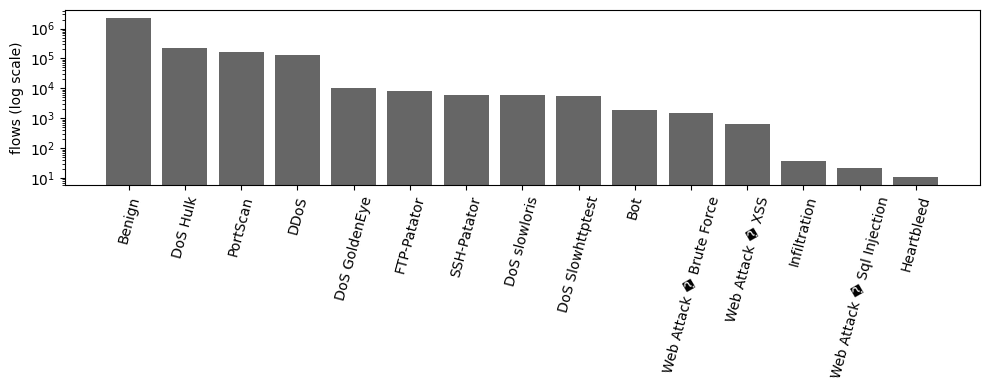

,label,count,pct
0,Benign,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


In [5]:
label_dist = (raw[LABEL_COLUMN].value_counts()
              .rename_axis("label").reset_index(name="count"))
label_dist["pct"] = (100 * label_dist["count"] / len(raw)).round(4)
label_dist.to_csv(P.eda / "label_distribution.csv", index=False)
log.info("%d classes; imbalance ratio max/min = %.0f",
         len(label_dist), label_dist["count"].max() / label_dist["count"].min())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(label_dist["label"], label_dist["count"], color="0.4")
ax.set_yscale("log")
ax.set_ylabel("flows (log scale)")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
fig.savefig(P.eda / "plots" / "label_distribution.png", dpi=150)
plt.show()
label_dist

## 4. Data quality: missing, infinite, zero, negative values per feature

In [6]:
feat = raw[CANONICAL_COLUMNS]
quality = pd.DataFrame({
    "n_nan": feat.isna().sum(),
    "n_inf": np.isinf(feat.to_numpy()).sum(axis=0),
    "n_zero": (feat == 0).sum(),
    "n_negative": (feat < 0).sum(),
})
quality.to_csv(P.eda / "feature_quality.csv")
zero_variance = feat.columns[feat.nunique() <= 1].tolist()
dq = {
    "total_nan": int(quality["n_nan"].sum()),
    "total_inf": int(quality["n_inf"].sum()),
    "features_with_nan": quality.index[quality["n_nan"] > 0].tolist(),
    "features_with_inf": quality.index[quality["n_inf"] > 0].tolist(),
    "zero_variance_features": zero_variance,
}
nbc.save_json(dq, P.eda / "data_quality.json")
log.info("NaN cells=%d | inf cells=%d | zero-variance features=%s",
         dq["total_nan"], dq["total_inf"], zero_variance or "none")
quality[(quality[["n_nan", "n_inf"]].sum(axis=1)) > 0]

2026-07-06 11:17:34,601 INFO nb01: NaN cells=1358 | inf cells=4376 | zero-variance features=['bwd_psh_flags', 'bwd_urg_flags', 'fwd_byts_b_avg', 'fwd_pkts_b_avg', 'fwd_blk_rate_avg', 'bwd_byts_b_avg', 'bwd_pkts_b_avg', 'bwd_blk_rate_avg']


,n_nan,n_inf,n_zero,n_negative
flow_byts_s,1358,1509,355767,85
flow_pkts_s,0,2867,0,115


## 5. Descriptive statistics (all 77 features)

In [7]:
desc = feat.describe().T
desc.to_csv(P.eda / "describe.csv")
log.info("saved describe.csv (%d features)", len(desc))
desc.head(15)

/Users/MAC/Projects/IDS/backend/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/MAC/Projects/IDS/backend/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


2026-07-06 11:17:41,543 INFO nb01: saved describe.csv (77 features)


,count,mean,std,min,25%,50%,75%,max
dst_port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04
flow_duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.000000,31316.000000,3.204828e+06,1.200000e+08
tot_fwd_pkts,2830743.0,9.361160e+00,7.496728e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05
tot_bwd_pkts,2830743.0,1.039377e+01,9.973883e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05
totlen_fwd_pkts,2830743.0,5.493024e+02,9.993589e+03,0.0,12.000000,62.000000,1.870000e+02,1.290000e+07
totlen_bwd_pkts,2830743.0,1.616264e+04,2.263088e+06,0.0,0.000000,123.000000,4.820000e+02,6.554530e+08
fwd_pkt_len_max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.000000,37.000000,8.100000e+01,2.482000e+04
fwd_pkt_len_min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.000000,2.000000,3.600000e+01,2.325000e+03
fwd_pkt_len_mean,2830743.0,5.820194e+01,1.860912e+02,0.0,6.000000,34.000000,5.000000e+01,5.940857e+03
fwd_pkt_len_std,2830743.0,6.891013e+01,2.811871e+02,0.0,0.000000,0.000000,2.616295e+01,7.125597e+03


In [8]:
log.info("notebook 01 complete — artifacts in %s", P.eda)
sorted(str(p.relative_to(P.root)) for p in P.eda.rglob("*") if p.is_file())

2026-07-06 11:17:41,586 INFO nb01: notebook 01 complete — artifacts in /Users/MAC/Projects/IDS/backend/artifacts/ft40_mi/cic2017/eda


['eda/data_quality.json',
 'eda/describe.csv',
 'eda/feature_quality.csv',
 'eda/label_distribution.csv',
 'eda/overview.json',
 'eda/plots/label_distribution.png']